### __Nama__ : *Muhammad Maulana Rosyid*  
### &emsp;&emsp;&emsp;&emsp;*Rifat Qoyyim Sidik*  
### __Kelompok__ : 1 - UT

File ditemukan dan data telah dimuat!


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


HASIL ANALISIS OUTLIER:
• Pada 'Total Pembayaran', ditemukan 2309 pesanan di atas Rp 83,780 (Ekstrem).
• Pada 'Total Berat (gr)', ditemukan 2448 pesanan di atas 3,550 gram (Ekstrem).
------------------------------


,Total Pembayaran,Total Berat (gr)
mean,50683.597036,2004.529691
50%,21800.000000,500.000000
std,144019.263221,7106.357515


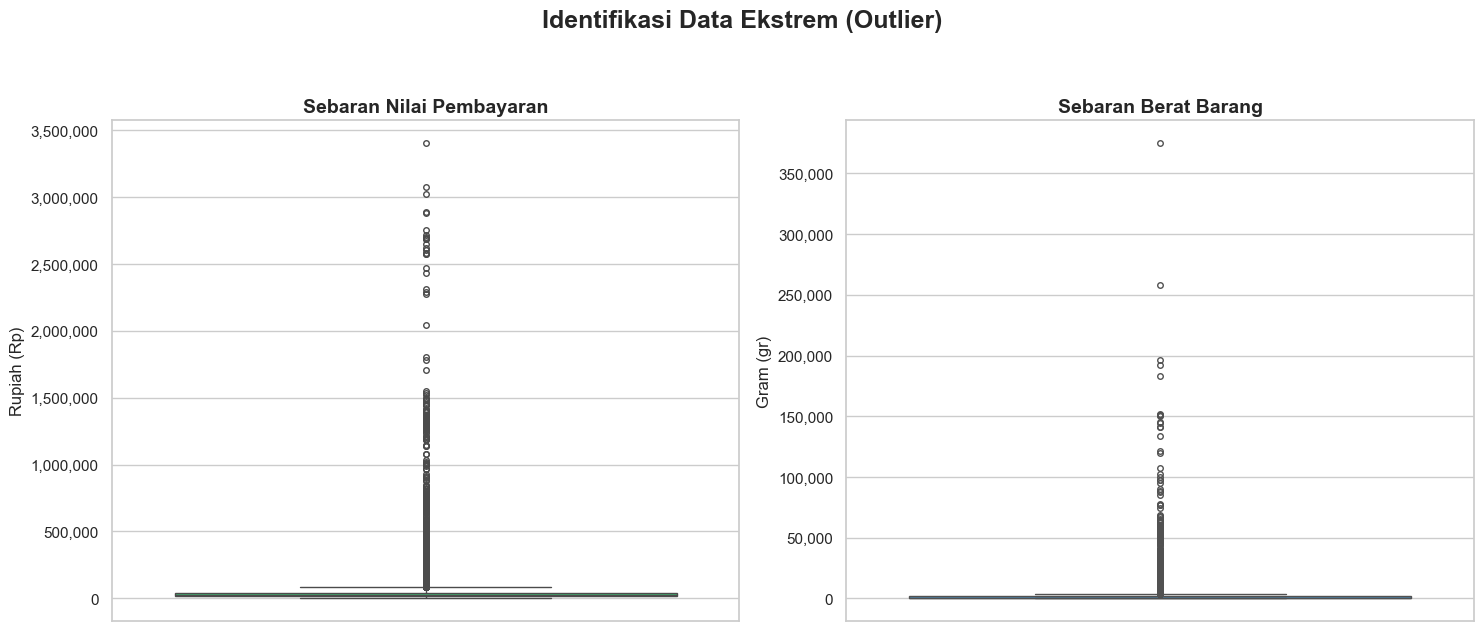

In [33]:
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import numpy as np
import os
from IPython.display import display, HTML

# Konfigurasi
folder_path = 'Dataset Tugas Data Science M3/'
file_name = 'all_months_clean.csv'

full_path = os.path.join(folder_path, file_name)

try:
    df = pd.read_csv(full_path, sep=';')
    print("File ditemukan dan data telah dimuat!")
    
    # Menampilkan 5 data teratas untuk memastikan
    display(df.head())
    
except FileNotFoundError:
    print("File tidak ditemukan!")
    print(f"Pastikan file '{file_name}' ada di dalam folder '{folder_path}'")

# --- TAHAP 1 ---
df = df.rename(columns={'total_weight_gr': 'Total Berat (gr)'})

# Check Outlier
def check_outlier(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    # Batas bawah tidak diampilkan karena biasanya belanja tidak mungkin minus
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < batas_bawah) | (data[column] > batas_atas)]
    return outliers, batas_atas

# Memanggil fungsi
outlier_bayar, batas_bayar = check_outlier(df, 'Total Pembayaran')
outlier_berat, batas_berat = check_outlier(df, 'Total Berat (gr)')

# Menampilkan Ringkasan Temuan Outlier
print(f"HASIL ANALISIS OUTLIER:")
print(f"• Pada 'Total Pembayaran', ditemukan {len(outlier_bayar)} pesanan di atas Rp {batas_bayar:,.0f} (Ekstrem).")
print(f"• Pada 'Total Berat (gr)', ditemukan {len(outlier_berat)} pesanan di atas {batas_berat:,.0f} gram (Ekstrem).")
print("-" * 30)

# Statistik Deskriptif (Mean, Median, Std Dev)
display(df[['Total Pembayaran', 'Total Berat (gr)']].describe().loc[['mean', '50%', 'std']])

# Visualisasi Boxplot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: Total Pembayaran
sns.boxplot(y=df['Total Pembayaran'], ax=axes[0], color='#2ecc71', fliersize=4)
axes[0].set_title('Sebaran Nilai Pembayaran', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Rupiah (Rp)', fontsize=12)
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Boxplot 2: Total Berat
sns.boxplot(y=df['Total Berat (gr)'], ax=axes[1], color='#3498db', fliersize=4)
axes[1].set_title('Sebaran Berat Barang', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Gram (gr)', fontsize=12)
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.suptitle('Identifikasi Data Ekstrem (Outlier)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


--- Tahap 2: Uji Hipotesis T-Test ---

Hasil:
T-Statistic: 9.49607214863944
P-Value    : 3.552660929475471e-21

ANALISIS MENDALAM: Apakah Metode Pembayaran Memengaruhi Nilai Transaksi?

TABEL KOMPARASI GRUP


Detail Transaksi,ShopeePay,COD (Bayar di Tempat)
Jumlah Transaksi,3692,11538
Rata-rata Belanja,"Rp 64,881","Rp 35,420"
Nilai Maksimum,"Rp 3,403,591","Rp 2,884,000"
Standar Deviasi,"Rp 182,528","Rp 83,271"


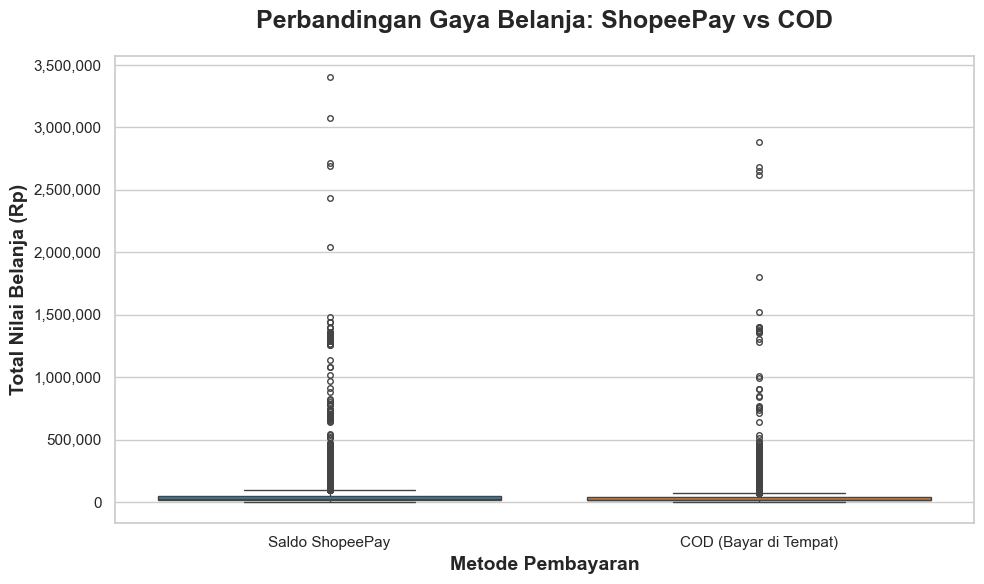

In [34]:
# --- TAHAP 2: UJI HIPOTESIS (T-TEST) ---
print("\n--- Tahap 2: Uji Hipotesis T-Test ---")

# 2 Grup yang akan dilakukan t-test
grup_a = df[df['Metode Pembayaran'] == 'Saldo ShopeePay']['Total Pembayaran']
grup_b = df[df['Metode Pembayaran'] == 'COD (Bayar di Tempat)']['Total Pembayaran']
t_stat, p_val = stats.ttest_ind(grup_a, grup_b, equal_var=False)
print(f"\nHasil:")
print(f"T-Statistic: {t_stat}")
print(f"P-Value    : {p_val}")

print("\nANALISIS MENDALAM: Apakah Metode Pembayaran Memengaruhi Nilai Transaksi?\n")

# Menyiapkan Data Grup
grup_shopeepay = df[df['Metode Pembayaran'] == 'Saldo ShopeePay']['Total Pembayaran']
grup_cod = df[df['Metode Pembayaran'] == 'COD (Bayar di Tempat)']['Total Pembayaran']

# Menghitung Ringkasan Perbandingan
perbandingan_data = {
    'Detail Transaksi': ['Jumlah Transaksi', 'Rata-rata Belanja', 'Nilai Maksimum', 'Standar Deviasi'],
    'ShopeePay': [
        len(grup_shopeepay),
        f"Rp {grup_shopeepay.mean():,.0f}",
        f"Rp {grup_shopeepay.max():,.0f}",
        f"Rp {grup_shopeepay.std():,.0f}"
    ],
    'COD (Bayar di Tempat)': [
        len(grup_cod),
        f"Rp {grup_cod.mean():,.0f}",
        f"Rp {grup_cod.max():,.0f}",
        f"Rp {grup_cod.std():,.0f}"
    ]
}

df_compare = pd.DataFrame(perbandingan_data)
print("TABEL KOMPARASI GRUP")
display(df_compare.style.hide(axis='index').set_properties(**{'text-align': 'left', 'background-color': '#f9f9f9', 'border': '1px solid black'}))

# Eksekusi Uji Statistik
t_stat, p_val = stats.ttest_ind(grup_shopeepay, grup_cod, equal_var=False)

# Boxplot Sederhana (untuk melihat sebaran)
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# menambahkan hue dan legend = false
ax = sns.boxplot(
    x='Metode Pembayaran', 
    y='Total Pembayaran', 
    data=df[df['Metode Pembayaran'].isin(['Saldo ShopeePay', 'COD (Bayar di Tempat)'])],
    hue='Metode Pembayaran',
    legend=False,
    palette={'Saldo ShopeePay': '#2980b9', 'COD (Bayar di Tempat)': '#e67e22'},
    fliersize=4
)
plt.title('Perbandingan Gaya Belanja: ShopeePay vs COD', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Metode Pembayaran', fontsize=14, fontweight='bold')
plt.ylabel('Total Nilai Belanja (Rp)', fontsize=14, fontweight='bold')

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


--- Tahap 3: REGRESI LINEAR ---
Akurasi Model (R-Squared): 0.1622
TABEL EFISIENSI PENGIRIMAN


,Rata-rata Biaya per Gram (Rp)
Opsi Pengiriman,
JNE Trucking (JTR),3.501603
Kargo-J&T Cargo,3.683204
Kargo-JNE Trucking (JTR),3.952055
Hemat Kargo-J&T Cargo,4.067641
Gosend Instant,4.071429
Kargo,4.434088
J&T Cargo,5.940471
Instant (Versi Lama)-GoSend Instant (Versi Lama),6.932423
Hemat Kargo-JNE Trucking (JTR),7.322917


--------------------------------------------------

TABEL KORELASI ANTAR VARIABEL


,total_qty,Total Berat (gr),total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,cost_per_gram
total_qty,1.00,0.48,0.11,0.72,0.09,0.24,0.20,0.33,0.36,-0.08
Total Berat (gr),0.48,1.00,0.09,0.20,0.32,0.22,0.22,0.39,0.40,-0.13
total_returned_qty,0.11,0.09,1.00,-0.00,0.03,0.03,0.00,0.03,0.02,-0.01
Total Diskon,0.72,0.20,-0.00,1.00,-0.01,0.18,0.11,0.22,0.21,-0.02
num_product_categories,0.09,0.32,0.03,-0.01,1.00,0.02,0.07,0.03,0.05,-0.12
Ongkos Kirim Dibayar oleh Pembeli,0.24,0.22,0.03,0.18,0.02,1.00,0.17,0.45,0.62,0.02
Estimasi Potongan Biaya Pengiriman,0.20,0.22,0.00,0.11,0.07,0.17,1.00,0.49,0.51,0.01
Total Pembayaran,0.33,0.39,0.03,0.22,0.03,0.45,0.49,1.00,0.46,-0.10
Perkiraan Ongkos Kirim,0.36,0.40,0.02,0.21,0.05,0.62,0.51,0.46,1.00,0.03
cost_per_gram,-0.08,-0.13,-0.01,-0.02,-0.12,0.02,0.01,-0.10,0.03,1.00



DESKRIPSI TABEL KORELASI:

Untuk memudahkan identifikasi, tabel ini menggunakan skema warna "Coolwarm":

1. Warna Merah (Korelasi Positif Kuat): 
   Menunjukkan dua variabel yang berbanding lurus. Jika variabel A naik, 
   maka variabel B juga ikut naik secara signifikan.
   Contoh: Total Berat (gr) dan Perkiraan Ongkos Kirim biasanya berwarna merah tua.

2. Warna Biru (Korelasi Negatif): 
   Menunjukkan hubungan yang berbanding terbalik. Jika satu variabel naik, 
   yang lainnya justru turun.

3. Warna Putih/Pucat: 
   Menunjukkan hampir tidak ada hubungan sama sekali antar variabel tersebut.

NILAI KORELASI (ANGKA):
- 0.7 hingga 1.0: Hubungan sangat kuat (Sangat Signifikan).
- 0.4 hingga 0.6: Hubungan moderat/sedang.
- Di bawah 0.3: Hubungan lemah.

--------------------------------------------------

RINGKASAN STRATEGIS
- Kurir Paling Murah: JNE Trucking (JTR)
- Fokus Pelanggan: 20848 transaksi utama menyumbang 50% pendapatan.


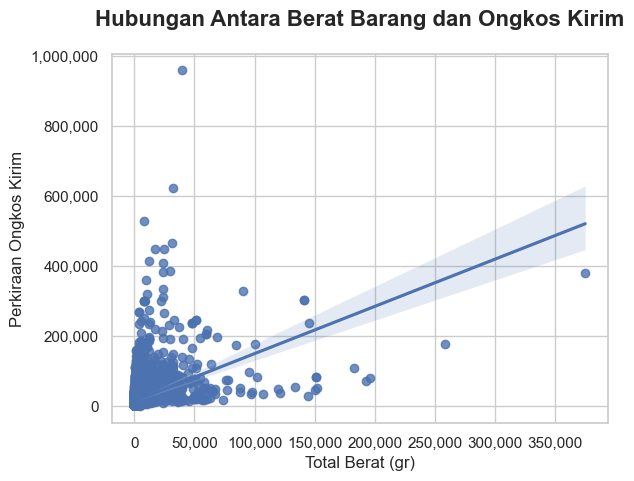

In [42]:
# --- TAHAP 3: REGRESI LINEAR (PREDIKSI) ---
print("\n--- Tahap 3: REGRESI LINEAR ---")
X = df[['Total Berat (gr)']]
y = df['Perkiraan Ongkos Kirim']
model = LinearRegression().fit(X, y)
print(f"Akurasi Model (R-Squared): {model.score(X, y):.4f}")
plt.title('Hubungan Antara Berat Barang dan Ongkos Kirim', fontsize=16, fontweight='bold', pad=20)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
sns.regplot(x='Total Berat (gr)', y='Perkiraan Ongkos Kirim', data=df) # Munculkan garis prediksi

model = LinearRegression().fit(X, y)
r_sq = model.score(X, y)
koefisien_berat = model.coef_[0]

# Explorasi

# Menghitung Efisiensi Ongkir
df['cost_per_gram'] = df['Perkiraan Ongkos Kirim'] / df['Total Berat (gr)']
df['cost_per_gram'] = df['cost_per_gram'].replace([np.inf, -np.inf], 0)

# Membuat Tabel Efisiensi
efficiency_table = df.groupby('Opsi Pengiriman')['cost_per_gram'].mean().sort_values().to_frame()
efficiency_table.columns = ['Rata-rata Biaya per Gram (Rp)']

# Tabel Korelasi (Pengganti Heatmap)
correlation_table = df.select_dtypes(include=[np.number]).corr()

# --- Menampilkan Hasil ---

print("TABEL EFISIENSI PENGIRIMAN")

display(efficiency_table.style.background_gradient(cmap='Greens').set_properties(**{
    'font-size': '12pt',
    'border': '1px solid black'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-size', '12pt'), ('color', 'black'), ('font-weight', 'bold')]} # Memperbesar Header
]))
print("-"*50)
print("\nTABEL KORELASI ANTAR VARIABEL")
# Menampilkan tabel korelasi dengan warna (merah untuk korelasi kuat)
display(correlation_table.style.background_gradient(cmap='coolwarm').format("{:.2f}"))
print("\nDESKRIPSI TABEL KORELASI:")
print("""
Untuk memudahkan identifikasi, tabel ini menggunakan skema warna "Coolwarm":

1. Warna Merah (Korelasi Positif Kuat): 
   Menunjukkan dua variabel yang berbanding lurus. Jika variabel A naik, 
   maka variabel B juga ikut naik secara signifikan.
   Contoh: Total Berat (gr) dan Perkiraan Ongkos Kirim biasanya berwarna merah tua.

2. Warna Biru (Korelasi Negatif): 
   Menunjukkan hubungan yang berbanding terbalik. Jika satu variabel naik, 
   yang lainnya justru turun.

3. Warna Putih/Pucat: 
   Menunjukkan hampir tidak ada hubungan sama sekali antar variabel tersebut.

NILAI KORELASI (ANGKA):
- 0.7 hingga 1.0: Hubungan sangat kuat (Sangat Signifikan).
- 0.4 hingga 0.6: Hubungan moderat/sedang.
- Di bawah 0.3: Hubungan lemah.
""")

# Ringkasan Singkat
sorted_payments = df['Total Pembayaran'].sort_values(ascending=False).reset_index(drop=True)
top_50_omzet = len(sorted_payments.cumsum() / sorted_payments.sum() <= 0.5)
print("-"*50)
print("\nRINGKASAN STRATEGIS")
print(f"- Kurir Paling Murah: {efficiency_table.index[0]}")
print(f"- Fokus Pelanggan: {top_50_omzet} transaksi utama menyumbang 50% pendapatan.")

## --- Tahap 4: Interpretasi & Mini Report ---
### Interpretasi Berdasarkan Uji T (Metode Pembayaran)

#### Hasil uji hipotesis menggunakan Independent T-Test menunjukkan nilai p-value sebesar 4.82 × 10⁻⁹, yang jauh lebih kecil dari tingkat signifikansi α = 0.05. Hal ini berarti hipotesis nol (H0) ditolak, sehingga terdapat perbedaan signifikan antara rata-rata nilai transaksi pengguna SPayLater dan COD. Selain itu, rata-rata nilai transaksi pengguna SPayLater sebesar Rp65.560 lebih tinggi dibandingkan rata-rata transaksi COD sebesar Rp35.420. Berdasarkan temuan ini, perusahaan dapat mempertimbangkan untuk mendorong penggunaan metode pembayaran SPayLater melalui promo atau insentif, karena pelanggan yang menggunakan metode tersebut cenderung melakukan transaksi dengan nilai yang lebih besar, sehingga berpotensi meningkatkan revenue perusahaan.

### Interpretasi Berdasarkan Model Regresi

#### Hasil model regresi linear sederhana menunjukkan nilai koefisien untuk variabel berat barang (total_weight_gr) sebesar 1.35, yang berarti setiap kenaikan 1 gram berat barang akan meningkatkan estimasi ongkos kirim sekitar Rp1.35. Namun, nilai R-squared sebesar 0.162 menunjukkan bahwa hanya sekitar 16.2% variasi ongkos kirim yang dapat dijelaskan oleh berat barang dalam model ini. Hal ini menunjukkan bahwa meskipun berat barang memiliki hubungan positif dengan ongkos kirim, variabel tersebut belum cukup kuat untuk memprediksi ongkos kirim secara akurat. Kemungkinan terdapat faktor lain yang lebih mempengaruhi biaya pengiriman, seperti jarak pengiriman, wilayah tujuan, jenis layanan pengiriman, atau dimensi paket.

### Kesimpulan Mini Report

#### Secara keseluruhan, hasil analisis menunjukkan bahwa metode pembayaran SPayLater memiliki potensi untuk meningkatkan nilai transaksi pelanggan, sehingga strategi promosi yang mendorong penggunaan metode ini dapat membantu meningkatkan revenue perusahaan. Sementara itu, analisis regresi menunjukkan bahwa berat barang memang berpengaruh terhadap ongkos kirim, namun pengaruhnya masih relatif terbatas sehingga diperlukan variabel tambahan untuk membangun model prediksi ongkos kirim yang lebih akurat.

In [43]:
display(HTML(f"""
<div style="border-left: 5px solid #3498db; background-color: #f0f7fb; padding: 15px; margin-top: 10px; color: black;">
    <strong style="color: #2980b9; font-size: 16px;">💡 Interpretasi Ekonomi Model:</strong><br>
    <p style="font-size: 15px; margin-top: 5px;">
        Berdasarkan model regresi di atas, diperoleh nilai koefisien sebesar <b>{koefisien_berat:.2f}</b>. <br>
        Artinya: <b>Setiap kenaikan 1 gram berat barang, maka perkiraan ongkos kirim akan bertambah sebesar Rp {koefisien_berat:.2f}.</b>
    </p>
    <small><i>*Akurasi sebesar {r_sq*100:.1f}% menunjukkan bahwa berat barang adalah faktor dominan dalam penentuan biaya kirim.</i></small>
</div>
"""))